In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
datafluvius = pd.read_csv("data/Data 2024/afname-2024.csv", sep=";")

datafluvius.head()

,Van (datum),Van (tijdstip),Tot (datum),Tot (tijdstip),EAN-code,Meter,Metertype,Register,Volume,Eenheid,Validatiestatus,Omschrijving
0,01-01-2024,00:00:00,01-01-2024,00:15:00,"=""541448800000018463""",NaN,AMR-meter,Afname Actief,"10,625",kWh,Gevalideerd,NaN
1,01-01-2024,00:00:00,01-01-2024,00:15:00,"=""541448800000018463""",NaN,AMR-meter,Afname Reactief,"0,000",kVArh,Gevalideerd,NaN
2,01-01-2024,00:00:00,01-01-2024,00:15:00,"=""541448800000018463""",NaN,AMR-meter,Afname Capacitief,"3,750",kVArh,Gevalideerd,NaN
3,01-01-2024,00:00:00,01-01-2024,00:15:00,"=""541448800000018463""",NaN,AMR-meter,Afname Inductief,"0,000",kVArh,Gevalideerd,NaN
4,01-01-2024,00:15:00,01-01-2024,00:30:00,"=""541448800000018463""",NaN,AMR-meter,Afname Actief,"10,625",kWh,Gevalideerd,NaN


In [9]:
import pandas as pd

df_afname_kwh = datafluvius[
    (datafluvius["Register"] == "Afname Actief") &
    (datafluvius["Eenheid"] == "kWh")
].copy()

# volume correct omzetten naar float (komma -> punt)
df_afname_kwh["Volume"] = (
    df_afname_kwh["Volume"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

# combineer datum + tijd naar één datetime
df_afname_kwh["datetime"] = pd.to_datetime(
    df_afname_kwh["Van (datum)"] + " " + df_afname_kwh["Van (tijdstip)"],
    dayfirst=True
)

# enkel gewenste kolommen
df_afname_kwh = df_afname_kwh[["datetime", "Volume"]].copy()

# hernoemen voor duidelijkheid
df_afname_kwh.columns = ["datetime", "afname_kwh"]

df_afname_kwh = df_afname_kwh.reset_index(drop=True)

In [10]:
df_afname_kwh.head()

,datetime,afname_kwh
0,2024-01-01 00:00:00,10.625
1,2024-01-01 00:15:00,10.625
2,2024-01-01 00:30:00,11.875
3,2024-01-01 00:45:00,13.750
4,2024-01-01 01:00:00,14.375


In [11]:
datafluvius_injectie = pd.read_csv("data/Data 2024/Yuso-quarter-hour-injection-2024.csv", sep=";")

datafluvius_injectie.head()

,EAN,Datum en tijdstip (UTC),Datum en tijdstip (Europa/Brussel),Energie (kWh)
0,EAN541448860008243540,2023-12-31 23:00:00,2024-01-01 00:00:00,0.0
1,EAN541448860008243540,2023-12-31 23:15:00,2024-01-01 00:15:00,0.0
2,EAN541448860008243540,2023-12-31 23:30:00,2024-01-01 00:30:00,0.0
3,EAN541448860008243540,2023-12-31 23:45:00,2024-01-01 00:45:00,0.0
4,EAN541448860008243540,2024-01-01 00:00:00,2024-01-01 01:00:00,0.0


In [ ]:
import pandas as pd

df_injectie = datafluvius_injectie.copy()

df_injectie["datetime"] = pd.to_datetime(
    df_injectie["Datum en tijdstip (Europa/Brussel)"],
    format="%Y-%m-%d %H:%M:%S"
)

# energie correct omzetten + afronden
    s = df_injectie["Energie (kWh)"].astype(str).str.replace(",", ".", regex=False)
    df_injectie["injectie_kwh"] = pd.to_numeric(s, errors="coerce").round(2)

# enkel gewenste kolommen
df_injectie = df_injectie[["datetime", "injectie_kwh"]].copy()

# index resetten
df_injectie = df_injectie.reset_index(drop=True)

In [14]:
df_injectie.head()

,datetime,injectie_kwh
0,2024-01-01 00:00:00,0.0
1,2024-01-01 00:15:00,0.0
2,2024-01-01 00:30:00,0.0
3,2024-01-01 00:45:00,0.0
4,2024-01-01 01:00:00,0.0


In [ ]:
print(sum(df_injectie["injectie_kwh"]))

364766.25


In [ ]:
import pandas as pd

# zorg dat beide dezelfde kolomnaam hebben
df_afname = df_afname_kwh.copy()
df_injectie = df_injectie.copy()

df_afname["datetime"] = pd.to_datetime(df_afname["datetime"])
df_injectie["datetime"] = pd.to_datetime(df_injectie["datetime"])

# merge op datetime
df_energy = pd.merge(
    df_afname,
    df_injectie,
    on="datetime",
    how="outer"
)

# sorteren
df_energy = df_energy.sort_values("datetime").reset_index(drop=True)

df_energy.head()

,datetime,afname_kwh,injectie_kwh
0,2025-01-01 00:00:00,10.000,0.0
1,2025-01-01 00:15:00,9.375,0.0
2,2025-01-01 00:30:00,11.875,0.0
3,2025-01-01 00:45:00,11.875,0.0
4,2025-01-01 01:00:00,11.250,0.0


In [ ]:
print(sum(df_energy["afname_kwh"]))

1732086.875


In [ ]:
df_verbruik = pd.read_excel('data/combined_electricity_consumption_2025.xlsx')

df_verbruik.head()

,Datum,verbruik,productie
0,2025-01-01 00:00:00,33.153172,0.0
1,2025-01-01 00:15:00,33.143776,0.0
2,2025-01-01 00:30:00,39.696608,0.0
3,2025-01-01 00:45:00,41.295508,0.0
4,2025-01-01 01:00:00,40.903996,0.0


In [ ]:
print(sum(df_verbruik["productie"]))

4628514.689492


In [ ]:
#kw naar kwh
df_verbruik["verbruik_kwh"] = df_verbruik["verbruik"] * 0.25
df_verbruik['productie_kwh'] = df_verbruik["productie"] * 0.25

In [ ]:
print(sum(df_verbruik["productie_kwh"]))

1157128.672373


In [ ]:
df_verbruik = df_verbruik.rename(columns={"Datum": "datetime"})

In [ ]:
df_energy = df_energy.merge(
    df_verbruik[["datetime", "verbruik_kwh", "productie_kwh"]],
    on="datetime",
    how="left"
)

In [ ]:
df_energy.head()

,datetime,afname_kwh,injectie_kwh,verbruik_kwh,productie_kwh
0,2025-01-01 00:00:00,10.000,0.0,8.288293,0.0
1,2025-01-01 00:15:00,9.375,0.0,8.285944,0.0
2,2025-01-01 00:30:00,11.875,0.0,9.924152,0.0
3,2025-01-01 00:45:00,11.875,0.0,10.323877,0.0
4,2025-01-01 01:00:00,11.250,0.0,10.225999,0.0


In [ ]:
df_energy["totaalverbruik"] = df_energy["afname_kwh"] + df_energy["productie_kwh"] - df_energy["injectie_kwh"]

df_energy.head()

,datetime,afname_kwh,injectie_kwh,verbruik_kwh,productie_kwh,totaalverbruik
0,2025-01-01 00:00:00,10.000,0.0,8.288293,0.0,10.000
1,2025-01-01 00:15:00,9.375,0.0,8.285944,0.0,9.375
2,2025-01-01 00:30:00,11.875,0.0,9.924152,0.0,11.875
3,2025-01-01 00:45:00,11.875,0.0,10.323877,0.0,11.875
4,2025-01-01 01:00:00,11.250,0.0,10.225999,0.0,11.250


In [ ]:
#download als excel
df_energy.to_excel("energie_orac_2025.xlsx", index=False)

In [ ]:
print(df_energy.isna().sum())

datetime             0
afname_kwh           0
injectie_kwh      6728
verbruik_kwh        39
productie_kwh       39
totaalverbruik    6766
dtype: int64


In [ ]:
print(sum(df_energy["productie_kwh"]))

nan


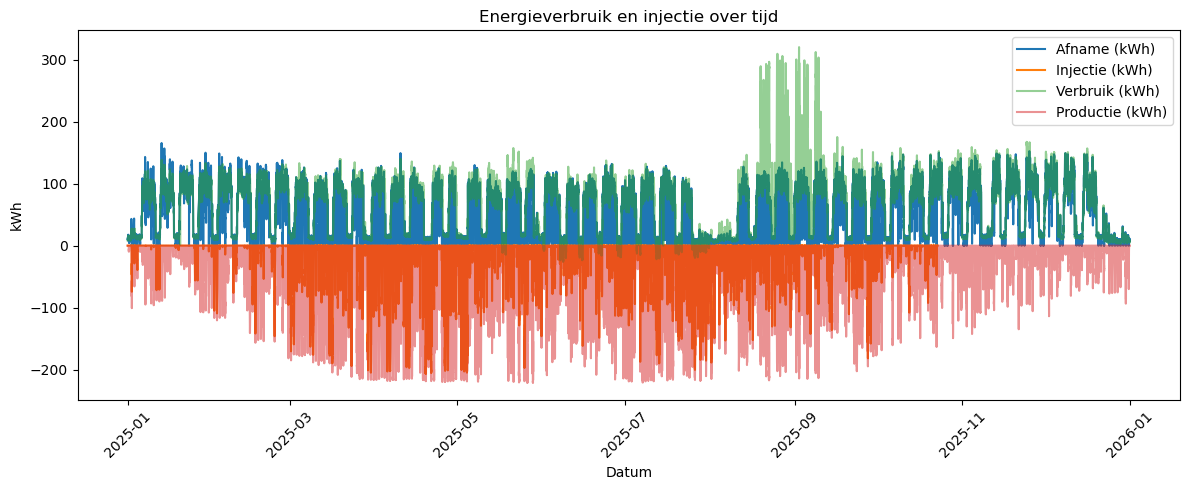

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(df_energy["datetime"], df_energy["afname_kwh"], label="Afname (kWh)")
plt.plot(df_energy["datetime"], -df_energy["injectie_kwh"], label="Injectie (kWh)")
plt.plot(df_verbruik["datetime"], df_verbruik["verbruik_kwh"], label="Verbruik (kWh)", alpha=0.5)
plt.plot(df_verbruik["datetime"], -df_verbruik["productie_kwh"], label="Productie (kWh)", alpha=0.5)

plt.xlabel("Datum")
plt.ylabel("kWh")
plt.title("Energieverbruik en injectie over tijd")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# zorg dat datetime echt datetime is
df_energy["datetime"] = pd.to_datetime(df_energy["datetime"])
df_verbruik["datetime"] = pd.to_datetime(df_verbruik["datetime"])

# filter augustus 2025 (pas jaar aan indien nodig)
start = "2025-08-01"
end = "2025-08-15"

df_energy_aug = df_energy[
    (df_energy["datetime"] >= start) &
    (df_energy["datetime"] < end)
]

df_verbruik_aug = df_verbruik[
    (df_verbruik["datetime"] >= start) &
    (df_verbruik["datetime"] < end)
]

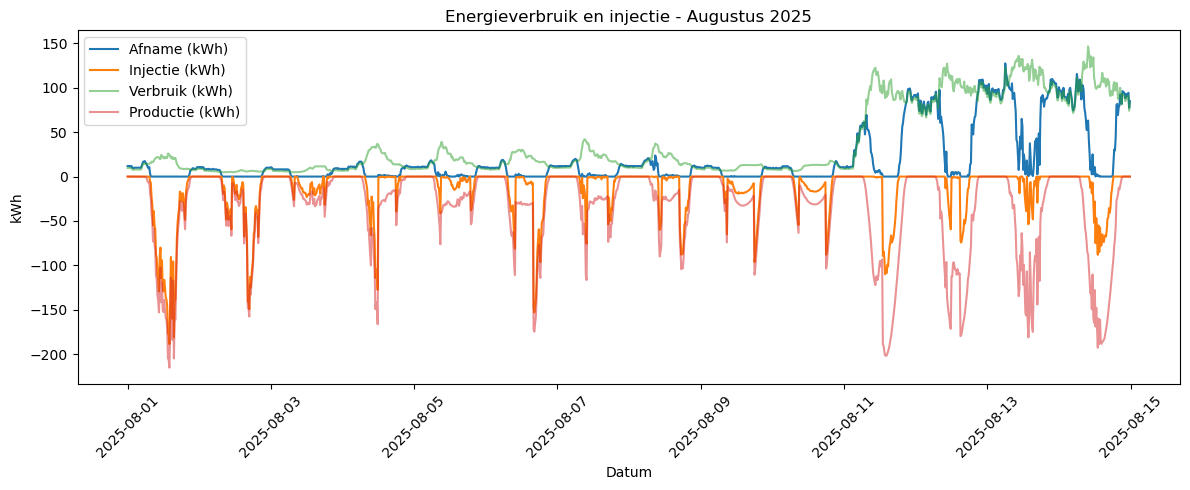

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(df_energy_aug["datetime"], df_energy_aug["afname_kwh"], label="Afname (kWh)")
plt.plot(df_energy_aug["datetime"], -df_energy_aug["injectie_kwh"], label="Injectie (kWh)")
plt.plot(df_verbruik_aug["datetime"], df_verbruik_aug["verbruik_kwh"], label="Verbruik (kWh)", alpha=0.5)
plt.plot(df_verbruik_aug["datetime"], -df_verbruik_aug["productie_kwh"], label="Productie (kWh)", alpha=0.5)

plt.xlabel("Datum")
plt.ylabel("kWh")
plt.title("Energieverbruik en injectie - Augustus 2025")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

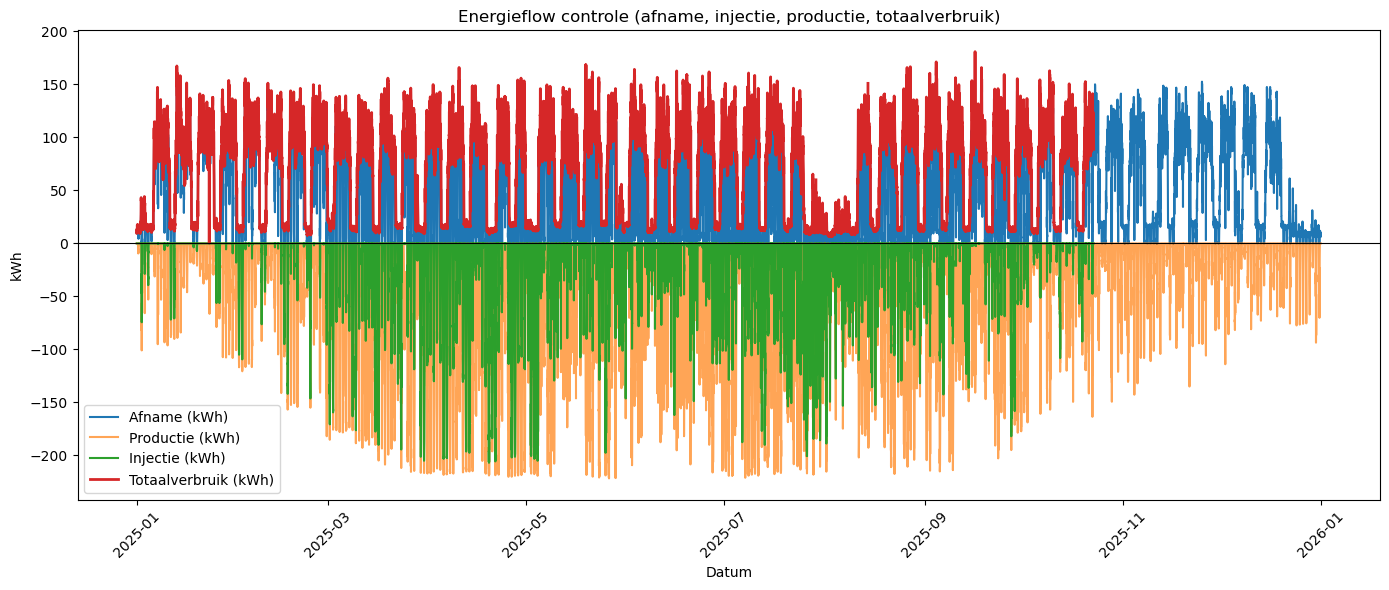

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df_energy["datetime"] = pd.to_datetime(df_energy["datetime"])

plt.figure(figsize=(14, 6))

# Afname
plt.plot(df_energy["datetime"], df_energy["afname_kwh"], label="Afname (kWh)")

# Productie
plt.plot(df_energy["datetime"], -df_energy["productie_kwh"], label="Productie (kWh)", alpha=0.7)
# Injectie (negatief voor visueel contrast)
plt.plot(df_energy["datetime"], -df_energy["injectie_kwh"], label="Injectie (kWh)")



# Totaalverbruik
plt.plot(df_energy["datetime"], df_energy["totaalverbruik"], label="Totaalverbruik (kWh)", linewidth=2)

plt.axhline(0, color="black", linewidth=0.8)

plt.xlabel("Datum")
plt.ylabel("kWh")
plt.title("Energieflow controle (afname, injectie, productie, totaalverbruik)")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

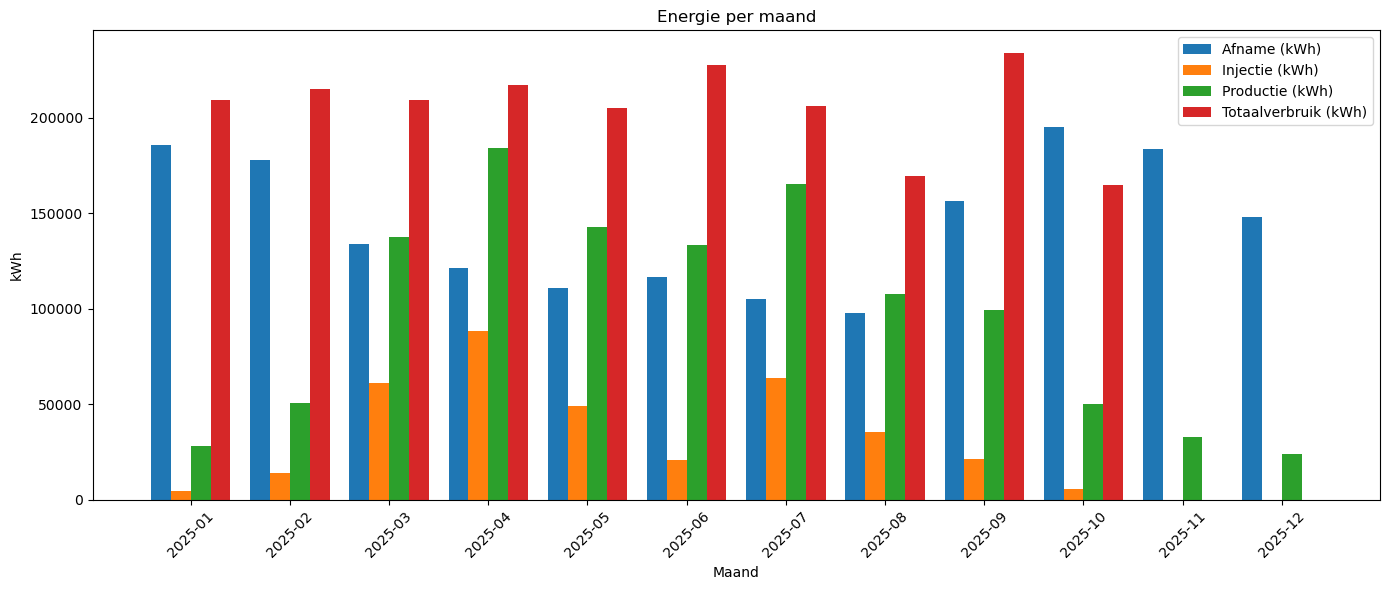

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_energy["datetime"] = pd.to_datetime(df_energy["datetime"])

# maandgroepering
df_month = df_energy.copy()
df_month["month"] = df_month["datetime"].dt.to_period("M")

df_monthly = df_month.groupby("month")[[
    "afname_kwh",
    "injectie_kwh",
    "productie_kwh",
    "totaalverbruik"
]].sum().reset_index()

df_monthly["month"] = df_monthly["month"].astype(str)

# x-as
x = np.arange(len(df_monthly["month"]))
width = 0.2

plt.figure(figsize=(14, 6))

plt.bar(x - 1.5*width, df_monthly["afname_kwh"], width, label="Afname (kWh)")
plt.bar(x - 0.5*width, df_monthly["injectie_kwh"], width, label="Injectie (kWh)")
plt.bar(x + 0.5*width, df_monthly["productie_kwh"], width, label="Productie (kWh)")
plt.bar(x + 1.5*width, df_monthly["totaalverbruik"], width, label="Totaalverbruik (kWh)")

plt.xticks(x, df_monthly["month"], rotation=45)

plt.xlabel("Maand")
plt.ylabel("kWh")
plt.title("Energie per maand")
plt.legend()

plt.tight_layout()
plt.show()

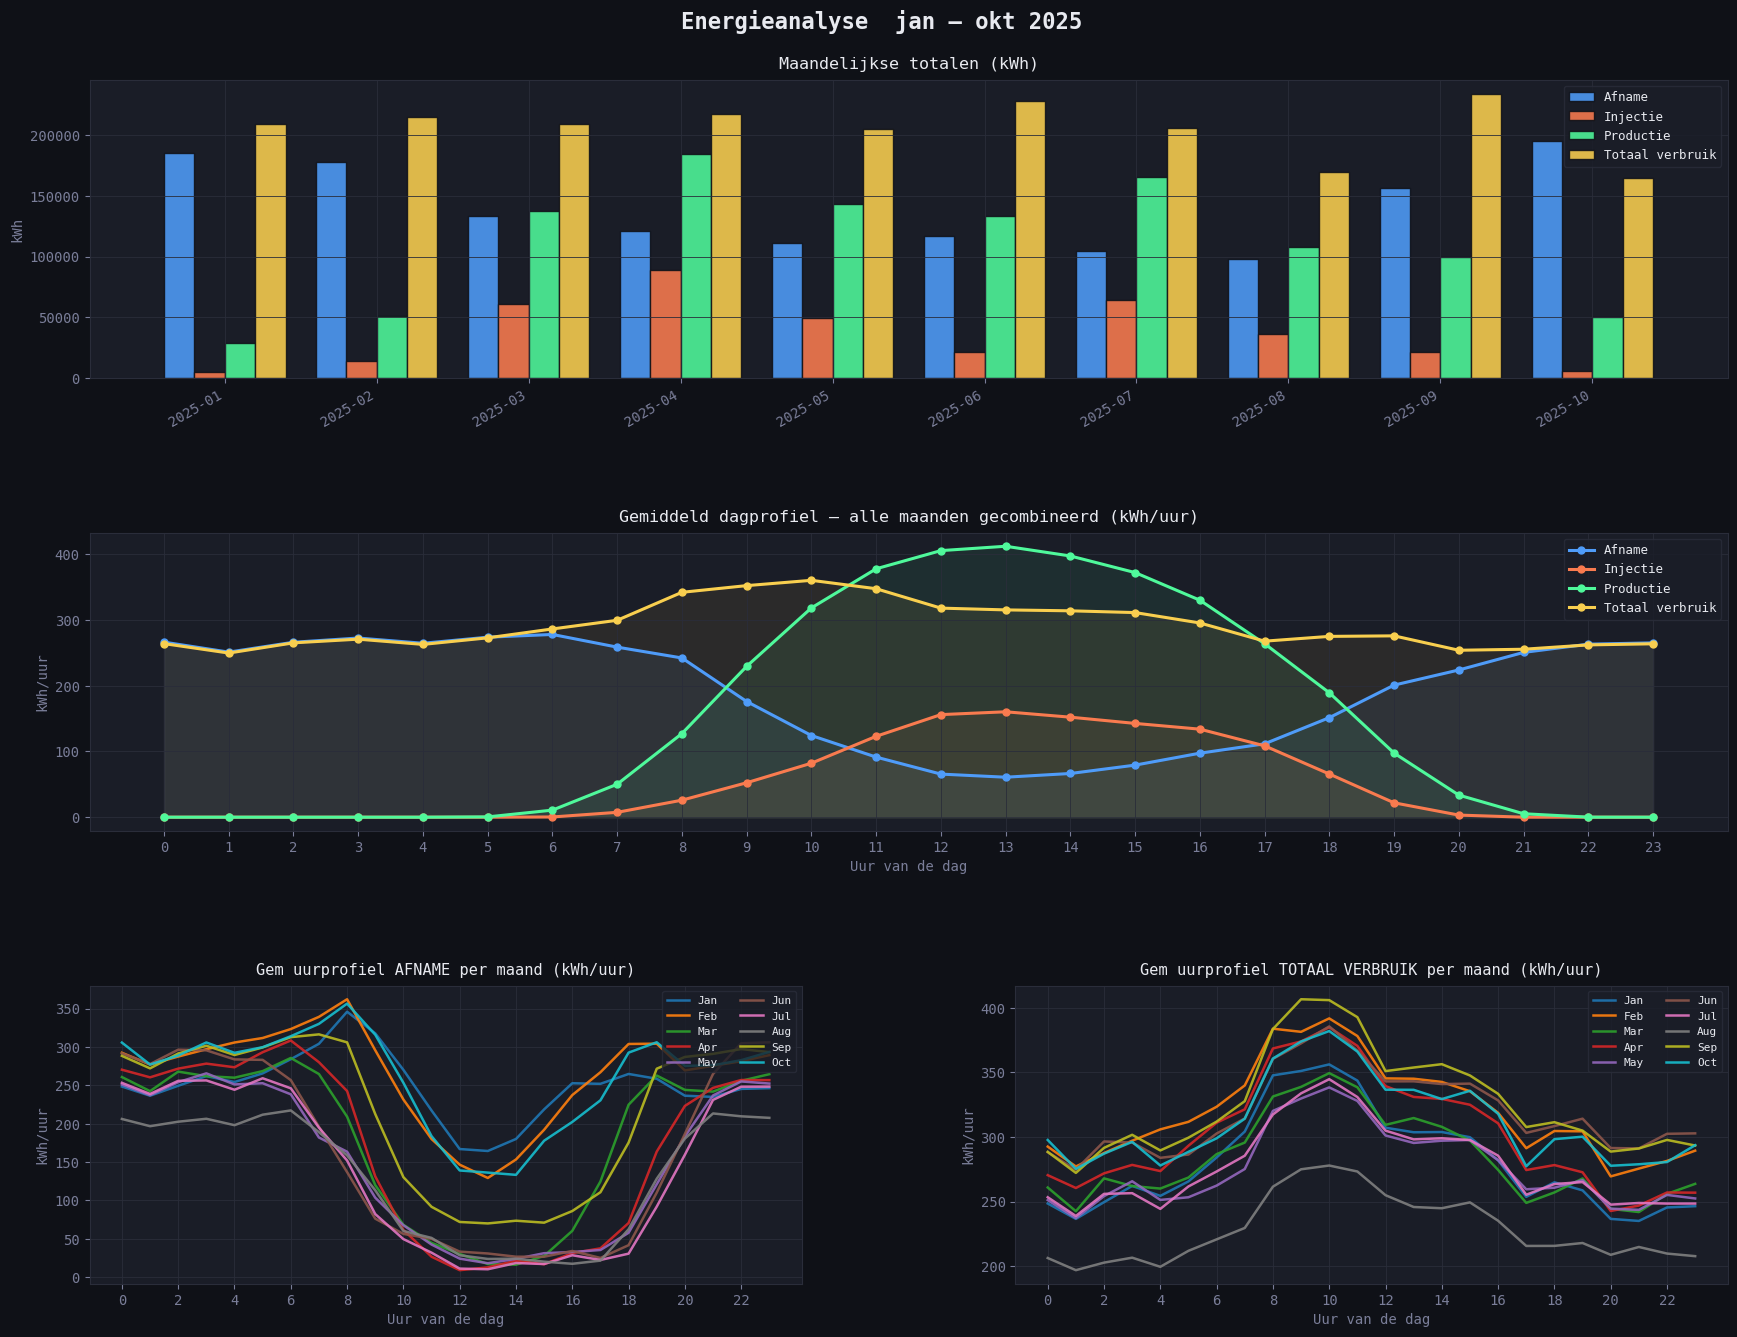

Opgeslagen als energie_analyse.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Filter jan–okt 2025 ───────────────────────────────────────────────────────
df_energy["datetime"] = pd.to_datetime(df_energy["datetime"])
mask = (df_energy["datetime"] >= "2025-01-01") & (df_energy["datetime"] < "2025-11-01")
df = df_energy[mask].copy()

# ── Afgeleide kolommen ────────────────────────────────────────────────────────
df["month"]     = df["datetime"].dt.to_period("M").astype(str)
df["hour"]      = df["datetime"].dt.hour
df["month_num"] = df["datetime"].dt.month

# ── Aggregaties ───────────────────────────────────────────────────────────────
# 1. Maandelijkse totalen
df_monthly = (df.groupby("month")[["afname_kwh","injectie_kwh","productie_kwh","totaalverbruik"]]
                .sum().reset_index())

# 2. Gemiddeld dagprofiel (per kwartier → uur) over volledige periode
df_hourly_avg = (df.groupby("hour")[["afname_kwh","injectie_kwh","productie_kwh","totaalverbruik"]]
                   .mean().reset_index())
# kWh per kwartier → kWh/uur: ×4
for col in ["afname_kwh","injectie_kwh","productie_kwh","totaalverbruik"]:
    df_hourly_avg[col] = df_hourly_avg[col] * 4

# 3. Gemiddeld uurverbruik PER MAAND
df_month_hour = (df.groupby(["month","month_num","hour"])[["afname_kwh","totaalverbruik"]]
                   .mean().reset_index())
df_month_hour["afname_kwh"]     *= 4
df_month_hour["totaalverbruik"] *= 4

# ── Stijl ─────────────────────────────────────────────────────────────────────
DARK_BG  = "#0f1117"; CARD_BG = "#1a1d27"; GRID_COL = "#2a2d3a"
COLORS   = {"afname_kwh": "#4f9cf9", "injectie_kwh": "#f97b4f",
            "productie_kwh": "#4ff99b", "totaalverbruik": "#f9cf4f"}
LABELS   = {"afname_kwh": "Afname", "injectie_kwh": "Injectie",
            "productie_kwh": "Productie", "totaalverbruik": "Totaal verbruik"}
TEXT     = "#e8eaf0"; SUBTEXT = "#7a7e99"
CMAP     = plt.cm.tab10

plt.rcParams.update({
    "figure.facecolor": DARK_BG, "axes.facecolor": CARD_BG,
    "axes.edgecolor": GRID_COL, "axes.labelcolor": TEXT,
    "axes.grid": True, "grid.color": GRID_COL, "grid.linewidth": 0.6,
    "xtick.color": SUBTEXT, "ytick.color": SUBTEXT,
    "text.color": TEXT, "font.family": "monospace",
    "legend.facecolor": CARD_BG, "legend.edgecolor": GRID_COL,
})

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Energieanalyse  jan – okt 2025", fontsize=16,
             fontweight="bold", color=TEXT, y=0.98)

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.52, wspace=0.30,
                       left=0.06, right=0.97, top=0.93, bottom=0.07)

months     = df_monthly["month"].tolist()
x          = np.arange(len(months))
bar_w      = 0.20

# ══════════════════════════════════════════════════════════════════════════════
# 1. Maandelijkse TOTALEN – gegroepeerde staafgrafiek
# ══════════════════════════════════════════════════════════════════════════════
ax1 = fig.add_subplot(gs[0, :])
offsets = [-1.5, -0.5, 0.5, 1.5]
for off, col in zip(offsets, ["afname_kwh","injectie_kwh","productie_kwh","totaalverbruik"]):
    ax1.bar(x + off*bar_w, df_monthly[col], bar_w,
            label=LABELS[col], color=COLORS[col], alpha=0.88, edgecolor=DARK_BG)

ax1.set_title("Maandelijkse totalen (kWh)", color=TEXT, fontsize=12, pad=8)
ax1.set_ylabel("kWh", color=SUBTEXT)
ax1.set_xticks(x); ax1.set_xticklabels(months, rotation=30, ha="right")
ax1.legend(loc="upper right", fontsize=9)

# ══════════════════════════════════════════════════════════════════════════════
# 2. Gemiddeld dagprofiel over volledige periode
# ══════════════════════════════════════════════════════════════════════════════
ax2 = fig.add_subplot(gs[1, :])
hrs = df_hourly_avg["hour"]
for col in ["afname_kwh","injectie_kwh","productie_kwh","totaalverbruik"]:
    ax2.plot(hrs, df_hourly_avg[col], marker="o", ms=5, lw=2.2,
             color=COLORS[col], label=LABELS[col])
    ax2.fill_between(hrs, df_hourly_avg[col], alpha=0.08, color=COLORS[col])

ax2.set_title("Gemiddeld dagprofiel – alle maanden gecombineerd (kWh/uur)", color=TEXT, fontsize=12, pad=8)
ax2.set_ylabel("kWh/uur", color=SUBTEXT); ax2.set_xlabel("Uur van de dag", color=SUBTEXT)
ax2.set_xticks(range(0, 24)); ax2.legend(loc="upper right", fontsize=9)

# ══════════════════════════════════════════════════════════════════════════════
# 3. Gem uurverbruik AFNAME per maand (heatmap-stijl lijnplot)
# ══════════════════════════════════════════════════════════════════════════════
ax3 = fig.add_subplot(gs[2, 0])
maanden_uniek = sorted(df_month_hour["month_num"].unique())
for i, mnum in enumerate(maanden_uniek):
    sub  = df_month_hour[df_month_hour["month_num"] == mnum].sort_values("hour")
    lbl  = pd.Period(f"2025-{mnum:02d}","M").strftime("%b")
    col  = CMAP(i / len(maanden_uniek))
    ax3.plot(sub["hour"], sub["afname_kwh"], lw=1.8, color=col, label=lbl, alpha=0.9)

ax3.set_title("Gem uurprofiel AFNAME per maand (kWh/uur)", color=TEXT, fontsize=11, pad=8)
ax3.set_ylabel("kWh/uur", color=SUBTEXT); ax3.set_xlabel("Uur van de dag", color=SUBTEXT)
ax3.set_xticks(range(0, 24, 2))
ax3.legend(loc="upper right", fontsize=8, ncol=2)

# ══════════════════════════════════════════════════════════════════════════════
# 4. Gem uurverbruik TOTAAL per maand
# ══════════════════════════════════════════════════════════════════════════════
ax4 = fig.add_subplot(gs[2, 1])
for i, mnum in enumerate(maanden_uniek):
    sub  = df_month_hour[df_month_hour["month_num"] == mnum].sort_values("hour")
    lbl  = pd.Period(f"2025-{mnum:02d}","M").strftime("%b")
    col  = CMAP(i / len(maanden_uniek))
    ax4.plot(sub["hour"], sub["totaalverbruik"], lw=1.8, color=col, label=lbl, alpha=0.9)

ax4.set_title("Gem uurprofiel TOTAAL VERBRUIK per maand (kWh/uur)", color=TEXT, fontsize=11, pad=8)
ax4.set_ylabel("kWh/uur", color=SUBTEXT); ax4.set_xlabel("Uur van de dag", color=SUBTEXT)
ax4.set_xticks(range(0, 24, 2))
ax4.legend(loc="upper right", fontsize=8, ncol=2)

plt.savefig("energie_analyse.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()
print("Opgeslagen als energie_analyse.png")